# Preprocessing dan Unsupervised Learning (Clustering)
## Segmentasi Risiko Pasien Berdasarkan Data Kesehatan (Stroke Prediction Dataset)

**Tujuan:** Membersihkan data kesehatan pasien yang masih mentah, lalu mengelompokkan pasien ke dalam beberapa segmen risiko menggunakan algoritma **K-Means Clustering**, tanpa menggunakan label target (`stroke`) sebagai bahan pengelompokan.

**Sumber Dataset:** Stroke Prediction Dataset (awalnya dipublikasikan di Kaggle oleh fedesoriano), berisi data klinis 5.110 pasien.

**Alur Notebook:**
1. Import Library
2. Memuat Dataset Mentah
3. Eksplorasi Data Awal (EDA)
4. Data Cleaning (missing value, duplikat, format tidak konsisten)
5. Encoding & Feature Selection
6. Scaling / Standardisasi
7. Menentukan Jumlah Cluster Optimal (Elbow Method & Silhouette Score)
8. Implementasi K-Means Clustering
9. Visualisasi Hasil Clustering
10. Evaluasi & Analisis Karakteristik Tiap Cluster


## 1. Import Library

 semua library yang dibutuhkan di awal:
- `pandas` & `numpy` → mengolah data dalam bentuk tabel (DataFrame)
- `matplotlib` & `seaborn` → membuat visualisasi/grafik
- `sklearn.preprocessing` → untuk standarisasi (scaling) dan encoding data kategorikal
- `sklearn.cluster` → algoritma K-Means
- `sklearn.metrics` → menghitung Silhouette Score
- `sklearn.decomposition` → PCA, untuk mereduksi banyak fitur menjadi 2 dimensi agar bisa divisualisasikan


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


%matplotlib inline
sns.set_style("whitegrid")

RANDOM_STATE = 42


## 2. Memuat Dataset Mentah

Dataset diambil langsung dari repository GitHub (mirror publik dari dataset Kaggle *Stroke Prediction Dataset*) menggunakan `pd.read_csv()` dengan URL langsung, sehingga notebook ini bisa dijalankan ulang oleh siapa saja tanpa perlu upload file manual.

Keterangan kolom:
| Kolom | Keterangan |
|---|---|
| id | ID unik pasien |
| gender | Jenis kelamin |
| age | Usia pasien |
| hypertension | 1 = punya hipertensi, 0 = tidak |
| heart_disease | 1 = punya penyakit jantung, 0 = tidak |
| ever_married | Status pernikahan |
| work_type | Jenis pekerjaan |
| Residence_type | Tipe tempat tinggal (urban/rural) |
| avg_glucose_level | Rata-rata kadar glukosa darah |
| bmi | Body Mass Index (indeks massa tubuh) |
| smoking_status | Status merokok |
| stroke | 1 = pernah stroke, 0 = tidak (**tidak dipakai saat clustering**, hanya untuk validasi di akhir) |


In [2]:
url = "https://raw.githubusercontent.com/karavokyrismichail/Stroke-Prediction---Random-Forest/main/healthcare-dataset-stroke-data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(url)

print("Ukuran dataset (baris, kolom):", df.shape)
df.head()


Ukuran dataset (baris, kolom): (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Eksplorasi Data Awal (EDA)

Sebelum membersihkan data perlu tahu dulu "penyakit" apa saja yang ada di dalam data:
- Tipe data tiap kolom (`.info()`)
- Statistik dasar kolom numerik (`.describe()`)
- Apakah ada missing value?
- Apakah ada duplikat?
- Apakah ada format/kategori yang tidak konsisten?


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [4]:
df.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### 3.1 Cek Missing Value

In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({"jumlah_missing": missing, "persen_missing": missing_percent.round(2)})


,jumlah_missing,persen_missing
id,0,0.00
gender,0,0.00
age,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
ever_married,0,0.00
work_type,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00
bmi,201,3.93


**Temuan:** Kolom `bmi` memiliki nilai kosong (missing value) yang cukup banyak. Ini akan  ditangani di tahap cleaning.

### 3.2 Cek Data Duplikat

In [6]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat (identik semua kolom): {jumlah_duplikat}")

jumlah_duplikat_id = df.duplicated(subset=['id']).sum()
print(f"Jumlah duplikat berdasarkan kolom 'id': {jumlah_duplikat_id}")


Jumlah baris duplikat (identik semua kolom): 0
Jumlah duplikat berdasarkan kolom 'id': 0


**Temuan:** Pada dataset ini, setelah dicek, **tidak ditemukan baris duplikat**. Ini penting untuk tetap dilaporkan secara jujur  proses pengecekan duplikat tetap wajib dilakukan sebagai bagian dari pipeline cleaning yang baik, meskipun hasilnya nihil pada dataset ini.

### 3.3 Cek Format / Kategori Tidak Konsisten

In [7]:
kolom_kategorikal = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for kolom in kolom_kategorikal:
    print(f"Kolom '{kolom}':", df[kolom].unique())
    print("-" * 60)


Kolom 'gender': <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
------------------------------------------------------------
Kolom 'ever_married': <StringArray>
['Yes', 'No']
Length: 2, dtype: str
------------------------------------------------------------
Kolom 'work_type': <StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
------------------------------------------------------------
Kolom 'Residence_type': <StringArray>
['Urban', 'Rural']
Length: 2, dtype: str
------------------------------------------------------------
Kolom 'smoking_status': <StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str
------------------------------------------------------------


**Temuan format tidak konsisten:**
1. Nama kolom `Residence_type` memakai huruf kapital di awal, sedangkan kolom lain memakai huruf kecil semua (`gender`, `work_type`, dst) → **tidak konsisten**, perlu diseragamkan.
2. Kolom `smoking_status` memiliki kategori `"Unknown"` yang sebenarnya adalah bentuk lain dari missing value (informasi tidak tersedia), bukan kategori merokok yang sebenarnya.
3. Kolom `gender` memiliki kategori `"Other"` dengan jumlah data sangat sedikit (outlier kategori) yang perlu diperhatikan.


In [8]:
print(df['gender'].value_counts())


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


## 4. Data Cleaning

Berdasarkan temuan EDA di atas,  lakukan pembersihan data dengan langkah-langkah berikut:

1. **Menyeragamkan nama kolom** → semua huruf kecil
2. **Menangani missing value** pada kolom `bmi` → diisi (imputasi) dengan **median**, bukan mean, karena median lebih tahan terhadap outlier/nilai ekstrem
3. **Menghapus baris duplikat** (meski hasil cek = 0, tetap  jalankan kodenya sebagai standar praktik yang baik)
4. **Menghapus kategori `Other` pada gender** karena datanya hanya 1 baris (tidak representatif, berpotensi jadi outlier saat clustering)
5. **Menghapus kolom `id`** karena hanya nomor identitas, tidak relevan untuk analisis pengelompokan


### 4.1 Menyeragamkan Nama Kolom

In [9]:
# .str.lower() mengubah semua nama kolom menjadi huruf kecil agar konsisten
df.columns = df.columns.str.lower()
df.columns


Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

### 4.2 Menangani Missing Value pada `bmi`

In [10]:
# Mengisi nilai kosong pada kolom bmi dengan nilai tengah (median) dari kolom itu sendiri
median_bmi = df['bmi'].median()
print(f"Median BMI yang digunakan untuk imputasi: {median_bmi}")

df['bmi'] = df['bmi'].fillna(median_bmi)

# Verifikasi: pastikan sudah tidak ada missing value lagi
print("\nJumlah missing value setelah imputasi:")
print(df.isnull().sum())


Median BMI yang digunakan untuk imputasi: 28.1

Jumlah missing value setelah imputasi:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


### 4.3 Menghapus Baris Duplikat

In [11]:
jumlah_sebelum = df.shape[0]
df = df.drop_duplicates()
jumlah_sesudah = df.shape[0]

print(f"Jumlah baris sebelum: {jumlah_sebelum}")
print(f"Jumlah baris sesudah: {jumlah_sesudah}")
print(f"Baris yang dihapus: {jumlah_sebelum - jumlah_sesudah}")


Jumlah baris sebelum: 5110
Jumlah baris sesudah: 5110
Baris yang dihapus: 0


### 4.4 Menangani Kategori Tidak Representatif (`gender = Other`)

In [12]:
df = df[df['gender'] != 'Other']
print("Sisa kategori gender:", df['gender'].unique())
print("Ukuran data setelah dibersihkan:", df.shape)


Sisa kategori gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Ukuran data setelah dibersihkan: (5109, 12)


### 4.5 Menghapus Kolom yang Tidak Relevan

In [13]:
df = df.drop(columns=['id'])
df.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 5. Encoding Data Kategorikal & Pemilihan Fitur (Feature Selection)

Algoritma K-Means bekerja berdasarkan **jarak antar titik data (distance-based)**, sehingga semua fitur yang digunakan harus berupa **angka**. Kolom kategorikal seperti `gender` atau `smoking_status` perlu diubah dulu menjadi angka melalui **Label Encoding**.

Untuk clustering ini,  pilih fitur-fitur yang relevan untuk menggambarkan **profil risiko kesehatan pasien**:
- `age` (usia)
- `hypertension` (hipertensi)
- `heart_disease` (penyakit jantung)
- `avg_glucose_level` (kadar glukosa)
- `bmi` (indeks massa tubuh)
- `smoking_status` (status merokok, setelah di-encode)

Kolom `stroke` **sengaja tidak dimasukkan** ke dalam proses clustering karena tujuannya adalah *unsupervised learning* murni (mengelompokkan tanpa tahu jawabannya). Kolom ini akan saya gunakan nanti hanya untuk **memvalidasi** apakah hasil cluster masuk akal secara medis.


In [14]:
df_encoded = df.copy()

# LabelEncoder mengubah kategori teks menjadi angka, contoh:
# 'never smoked' -> 0, 'formerly smoked' -> 1, dst (urutan otomatis oleh sklearn)
le_smoking = LabelEncoder()
df_encoded['smoking_status_encoded'] = le_smoking.fit_transform(df_encoded['smoking_status'])

print("Mapping kategori smoking_status ke angka:")
for kategori, angka in zip(le_smoking.classes_, range(len(le_smoking.classes_))):
    print(f"  {kategori} -> {angka}")


Mapping kategori smoking_status ke angka:
  Unknown -> 0
  formerly smoked -> 1
  never smoked -> 2
  smokes -> 3


In [15]:
# Fitur yang dipakai untuk clustering
fitur_cluster = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'smoking_status_encoded']

X = df_encoded[fitur_cluster]
X.head()


,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_encoded
0,67.0,0,1,228.69,36.6,1
1,61.0,0,0,202.21,28.1,2
2,80.0,0,1,105.92,32.5,2
3,49.0,0,0,171.23,34.4,3
4,79.0,1,0,174.12,24.0,2


## 6. Scaling / Standarisasi Data

Perhatikan bahwa skala tiap fitur sangat berbeda:
- `age` berkisar 0–82
- `avg_glucose_level` berkisar puluhan hingga ratusan
- `hypertension` hanya berisi 0 atau 1

Jika tidak diseragamkan, K-Means akan **bias** ke fitur dengan skala angka lebih besar (misal `avg_glucose_level`) karena jarak Euclidean yang dipakai K-Means sangat dipengaruhi oleh skala angka.

 gunakan **StandardScaler**, yang mengubah setiap fitur menjadi memiliki **rata-rata = 0** dan **standar deviasi = 1**.


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ubah kembali ke DataFrame supaya mudah dibaca (opsional, hanya untuk pengecekan)
X_scaled_df = pd.DataFrame(X_scaled, columns=fitur_cluster)
X_scaled_df.describe().round(2)


,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_encoded
count,5109.00,5109.00,5109.00,5109.00,5109.00,5109.00
mean,0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.91,-0.33,-0.24,-1.13,-2.41,-1.29
25%,-0.81,-0.33,-0.24,-0.64,-0.66,-1.29
50%,0.08,-0.33,-0.24,-0.31,-0.10,0.58
75%,0.79,-0.33,-0.24,0.18,0.51,0.58
max,1.71,3.04,4.18,3.66,8.93,1.51


## 7. Menentukan Jumlah Cluster Optimal

Sebelum menjalankan K-Means,  perlu tahu berapa jumlah cluster (K) yang paling baik. Ada dua metode yang  dipakai bersamaan:

1. **Elbow Method**: menjalankan K-Means untuk beberapa nilai K (misal 1 sampai 10), lalu melihat nilai **WCSS/inertia** (total jarak titik data ke pusat clusternya). Titik di mana grafik mulai melandai membentuk "siku" (elbow) adalah kandidat K yang baik.
2. **Silhouette Score**: mengukur seberapa baik pemisahan antar cluster, dengan skor antara -1 sampai 1 (semakin tinggi semakin baik). Ini membantu memastikan pilihan K dari Elbow Method benar-benar menghasilkan cluster yang terpisah dengan baik.


In [ ]:
wcss = []       # untuk elbow method
silhouette_scores = []  # untuk silhouette score

k_range = range(2, 11)  

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

    print(f"K={k} | WCSS={kmeans.inertia_:.2f} | Silhouette Score={silhouette_scores[-1]:.4f}")


K=2 | WCSS=24265.29 | Silhouette Score=0.3861


K=3 | WCSS=19529.11 | Silhouette Score=0.2290


K=4 | WCSS=15081.09 | Silhouette Score=0.2925


K=5 | WCSS=12525.84 | Silhouette Score=0.3230


K=6 | WCSS=10588.62 | Silhouette Score=0.3225


K=7 | WCSS=9401.22 | Silhouette Score=0.3262


K=8 | WCSS=8574.12 | Silhouette Score=0.3137


K=9 | WCSS=7941.05 | Silhouette Score=0.3176


K=10 | WCSS=7456.79 | Silhouette Score=0.3164


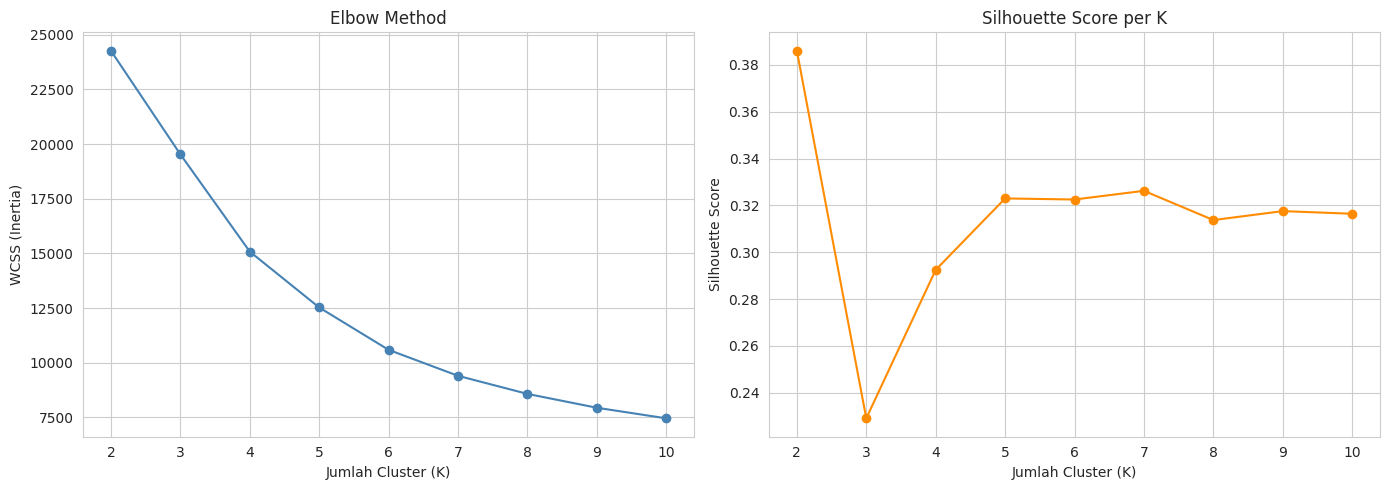

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik Elbow Method
axes[0].plot(list(k_range), wcss, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('WCSS (Inertia)')

# Grafik Silhouette Score
axes[1].plot(list(k_range), silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score per K')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


In [19]:
K_OPTIMAL = 4  # dipilih berdasarkan kombinasi Elbow Method + Silhouette Score (lihat penjelasan di atas)
print(f"Jumlah cluster yang dipilih: K = {K_OPTIMAL}")


Jumlah cluster yang dipilih: K = 4


## 8. Implementasi K-Means Clustering

Sekarang saya jalankan K-Means dengan nilai K yang sudah ditentukan, lalu menyimpan hasil label cluster ke dalam dataframe asli (yang belum di-scale) supaya mudah dianalisis maknanya.


In [20]:
kmeans_final = KMeans(n_clusters=K_OPTIMAL, init='k-means++', random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Menyimpan label cluster ke dataframe yang masih human-readable (belum di-scale)
df_encoded['cluster'] = cluster_labels

print("Jumlah pasien di tiap cluster:")
print(df_encoded['cluster'].value_counts().sort_index())


Jumlah pasien di tiap cluster:
cluster
0    2986
1    1413
2     434
3     276
Name: count, dtype: int64


In [21]:
final_silhouette = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score untuk K={K_OPTIMAL}: {final_silhouette:.4f}")


Silhouette Score untuk K=4: 0.2925


## 9. Visualisasi Hasil Clustering

Karena saya menggunakan 6 fitur sekaligus (data berdimensi tinggi), data tidak bisa langsung memvisualisasikannya dalam grafik 2D. Ada dua pendekatan yang saya pakai:

1. **Scatter plot 2 fitur asli** yang paling relevan secara medis: `age` vs `avg_glucose_level`
2. **PCA (Principal Component Analysis)**: mereduksi 6 fitur menjadi 2 "komponen utama" yang tetap merepresentasikan sebagian besar informasi asli, sehingga bisa digambar dalam scatter plot 2D


### 9.1 Scatter Plot: Usia vs Kadar Glukosa

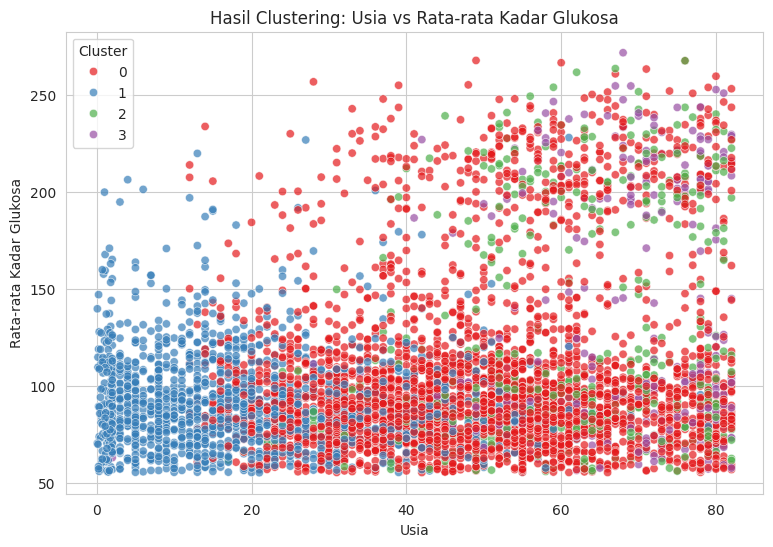

In [22]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_encoded,
    x='age',
    y='avg_glucose_level',
    hue='cluster',
    palette='Set1',
    alpha=0.7
)
plt.title('Hasil Clustering: Usia vs Rata-rata Kadar Glukosa')
plt.xlabel('Usia')
plt.ylabel('Rata-rata Kadar Glukosa')
plt.legend(title='Cluster')
plt.show()


### 9.2 Visualisasi dengan PCA (2 Dimensi)

Total variansi data yang berhasil dijelaskan oleh 2 komponen PCA: 49.41%


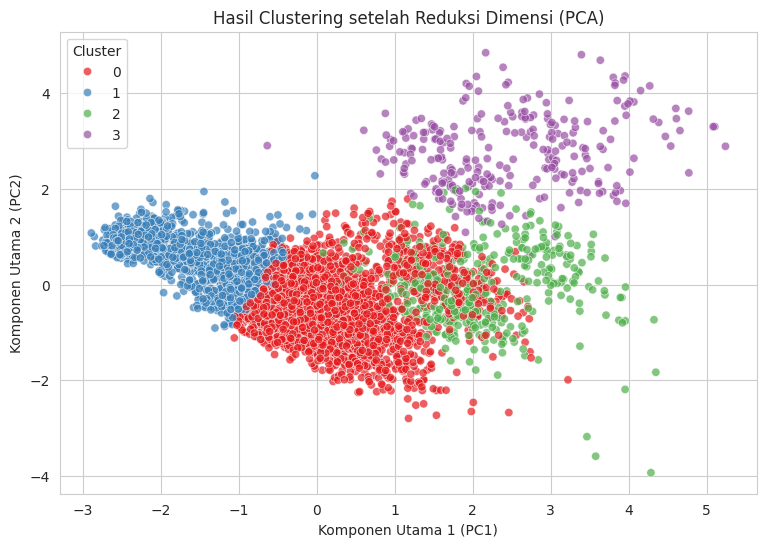

In [23]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Total variansi data yang berhasil dijelaskan oleh 2 komponen PCA: {pca.explained_variance_ratio_.sum()*100:.2f}%")

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette='Set1',
    alpha=0.7
)
plt.title('Hasil Clustering setelah Reduksi Dimensi (PCA)')
plt.xlabel('Komponen Utama 1 (PC1)')
plt.ylabel('Komponen Utama 2 (PC2)')
plt.legend(title='Cluster')
plt.show()


## 10. Evaluasi & Analisis Karakteristik Tiap Cluster

Selain Silhouette Score, cara paling mudah dipahami untuk mengevaluasi hasil clustering adalah dengan melihat **karakteristik rata-rata tiap cluster**. Dari sini saya bisa memberi "nama" atau interpretasi untuk tiap kelompok, misalnya "kelompok risiko tinggi" atau "kelompok usia muda sehat".


In [24]:
profil_cluster = df_encoded.groupby('cluster')[['age', 'hypertension', 'heart_disease',
                                                     'avg_glucose_level', 'bmi']].mean().round(2)
profil_cluster


,age,hypertension,heart_disease,avg_glucose_level,bmi
cluster,,,,,
0,50.02,0.00,0.0,106.89,31.13
1,18.54,0.00,0.0,92.13,22.64
2,61.02,1.00,0.0,127.09,32.79
3,68.19,0.23,1.0,136.82,30.05


### Validasi Tambahan (Opsional): Membandingkan dengan Kolom `stroke`

Ingat, kolom `stroke` **tidak digunakan** saat proses clustering. Tapi sekarang, sebagai validasi eksternal, data bisa lihat: apakah cluster dengan profil usia lebih tua, glukosa lebih tinggi, dsb, memang punya persentase pasien stroke yang lebih tinggi juga? Jika iya, ini menguatkan bahwa hasil clustering  masuk akal secara medis.


In [25]:
persentase_stroke = df_encoded.groupby('cluster')['stroke'].mean() * 100
persentase_stroke = persentase_stroke.round(2)

print("Persentase pasien yang pernah mengalami stroke per cluster:")
print(persentase_stroke)


Persentase pasien yang pernah mengalami stroke per cluster:
cluster
0     4.86
1     0.28
2    12.21
3    17.03
Name: stroke, dtype: float64


/tmp/ipykernel_567/4151862653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=persentase_stroke.index, y=persentase_stroke.values, palette='Set1')


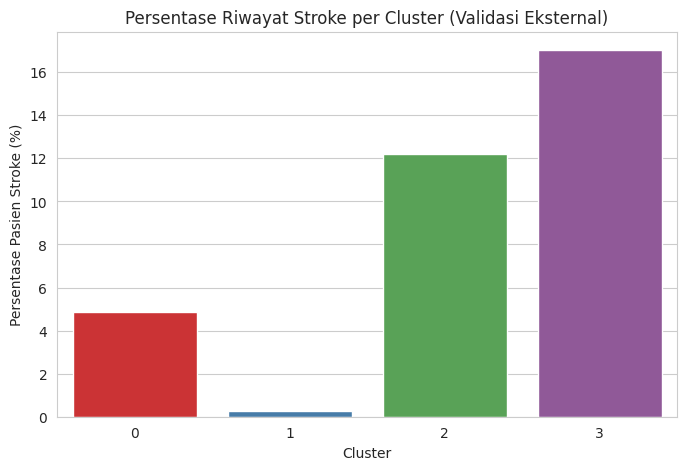

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(x=persentase_stroke.index, y=persentase_stroke.values, palette='Set1')
plt.title('Persentase Riwayat Stroke per Cluster (Validasi Eksternal)')
plt.xlabel('Cluster')
plt.ylabel('Persentase Pasien Stroke (%)')
plt.show()
